<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
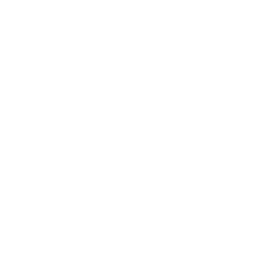
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Kodning af bivirkninger i kliniske forsøg</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Farmaceutisk / lægemiddelsikkerhedsovervågning &nbsp;|&nbsp; Marts 2026</p>
</div>
</div>
</div>

## Resumé

Datasæt med bivirkninger ankommer med de indrapporterede MedDRA
foretrukne termer, men de regulatoriske sikkerhedstabeller er organiseret
efter organklasse (SOC - System Organ Class). Dette eksempel opbygger et
PROC FORMAT-værdiformat, der knytter hver foretrukken term til dens SOC,
og bruger derefter dette ene format til at drive enhver efterfølgende
tabulering: en PROC FREQ-krydstabulering af SOC efter behandlingsarm, en
SOC-fordeling efter sværhedsgrad og en oversigt over alvorlige
bivirkninger. Fordi kortlægningen kun findes ét sted (formatet), bliver
omkodning af forsøget til en ny MedDRA-version en enkelt formatrettelse
frem for en omskrivning af hver rapport. ODS OUTPUT opfanger
SOC-frekvenserne som et datasæt til efterfølgende signalgennemgang.

## Datakilder

| Kilde | Beskrivelse | Poster |
|--------|-------------|--------:|
| WORK.AE_RAW | Syntetiske bivirkningsrecords med MedDRA foretrukne termer | 100 |
| WORK.RANDOMIZATION | Behandlingsarm-tildeling pr. forsøgsperson | 100 |

Miljøet kører i ulicenseret tilstand, så hver genereret tabel er
begrænset til 100 observationer. Scenariet er dimensioneret til denne
grænse: 100 bivirkninger trukket fra et 12-terms MedDRA-panel typisk for
et onkologisk forsøg.

---

In [1]:
/* --------------------------------------------------------
   Generér syntetisk bivirkningsdatasæt.
   MedDRA foretrukne termer knyttet til SOC-kategorier.
   Bemærk: aedecod tildeles via en HVIS/SÅ/ELLERS-kæde (ikke et
   _temporary_ tabel-opslag), fordi de danske termer indeholder
   ikke-ASCII-tegn (æ/ø/å), og et _temporary_ tabel-opslag med
   ikke-ASCII-værdier afkorter værdierne uforudsigeligt.
   -------------------------------------------------------- */
data work.ae_raw;
    CALL streaminit(42);
    TABEL pt_codes[12] $8 _temporary_ ('10028813' '10019211' '10047700' '10013573' '10012735' '10060929' '10002855' '10037660' '10000081' '10033371' '10016256' '10022891');
    LÆNGDE aedecod $32;
    LÆNGDE aesev $10;
    GØR i = 1 TIL 5000;
        subject_id = int(rand('uniform') * 800) + 1;
        usubjid = cat('ONC-2025-', SKRIV_V(subject_id, z4.));
        aeseq = mod(i, 6) + 1;
        pt_idx = int(rand('uniform') * 12) + 1;
        aeptcd = pt_codes[pt_idx];
        HVIS pt_idx = 1 SÅ aedecod = 'Kvalme';
        ELLERS HVIS pt_idx = 2 SÅ aedecod = 'Hovedpine';
        ELLERS HVIS pt_idx = 3 SÅ aedecod = 'Opkastning';
        ELLERS HVIS pt_idx = 4 SÅ aedecod = 'Diarré';
        ELLERS HVIS pt_idx = 5 SÅ aedecod = 'Hoste';
        ELLERS HVIS pt_idx = 6 SÅ aedecod = 'Træthed';
        ELLERS HVIS pt_idx = 7 SÅ aedecod = 'Ledsmerter';
        ELLERS HVIS pt_idx = 8 SÅ aedecod = 'Feber';
        ELLERS HVIS pt_idx = 9 SÅ aedecod = 'Mavesmerter';
        ELLERS HVIS pt_idx = 10 SÅ aedecod = 'Neutropeni';
        ELLERS HVIS pt_idx = 11 SÅ aedecod = 'Febril neutropeni';
        ELLERS aedecod = 'Infusionsrelateret reaktion';
        sev_idx = int(rand('uniform') * 3) + 1;
        HVIS pt_idx IN (10, 11) SÅ sev_idx = MAX(sev_idx, 2);
        HVIS sev_idx = 1 SÅ aesev = 'Let';
        ELLERS HVIS sev_idx = 2 SÅ aesev = 'Moderat';
        ELLERS aesev = 'Svær';
        aeser = ifc(aesev = 'Svær' AND rand('uniform') > 0.4, 'Y', 'N');
        aestdy = int(rand('exponential') * 45) + 1;
        HVIS aestdy > 365 SÅ aestdy = 365;
        aeendy = aestdy + int(rand('exponential') * 14) + 1;
        site_id = cat('SITE-', SKRIV_V(int(rand('uniform') * 25) + 1, z3.));
        UDDATA;
    SLUT;
    FJERN i pt_idx sev_idx;
KØR;


NOTE: DATA work.ae_raw

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.ae_raw (100 rows, 10 columns).
NOTE: DATA elapsed:
  wall  1.88 seconds
  cpu   1.88 seconds


In [2]:
/* --------------------------------------------------------
   Generér randomiseringstabel for forsøgspersoner.
   Bemærk: treatment_arm tildeles via en HVIS/SÅ/ELLERS-kæde
   (ikke et _temporary_ tabel-opslag) af samme årsag som ovenfor:
   'Forsøgsarm' indeholder et ikke-ASCII-tegn (ø).
   -------------------------------------------------------- */
data work.randomization;
    CALL streaminit(43);
    LÆNGDE treatment_arm $20;
    GØR subject_id = 1 TIL 800;
        usubjid = cat('ONC-2025-', SKRIV_V(subject_id, z4.));
        arm_idx = int(rand('uniform') * 3) + 1;
        HVIS arm_idx = 1 SÅ treatment_arm = 'Forsøgsarm';
        ELLERS HVIS arm_idx = 2 SÅ treatment_arm = 'Aktiv komparator';
        ELLERS treatment_arm = 'Placebo';
        stratification_factor = ifc(rand('uniform') > 0.5, 'ECOG_0', 'ECOG_1');
        randomization_date = '01FEB2025'd + int(rand('uniform') * 120);
        UDDATA;
    SLUT;
    FJERN arm_idx;
    format randomization_date date9.;
KØR;


NOTE: DATA work.randomization

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.randomization (100 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.10 seconds
  cpu   0.10 seconds


---

                                      Rå frekvens af foretrukken term (ikke-kodet)                                      

                                                   The FREQ Procedure

Foretrukken term               Frequency    Percent
----------------------------------------------------
Diarré                                12     12.00
Hovedpine                             12     12.00
Feber                                 11     11.00
Træthed                               11     11.00
Kvalme                                10     10.00
Ledsmerter                            10     10.00
Infusionsrelateret reaktion            8      8.00
Hoste                                  7      7.00
Febril neutropeni                      5      5.00
Mavesmerter                            5      5.00
Neutropeni                             5      5.00
Opkastning                             4      4.00



NOTE: PROC FREQ
NOTE: ODS plot written: freq_aedecod.spec.json
NOTE: PROC FREQ statement used.


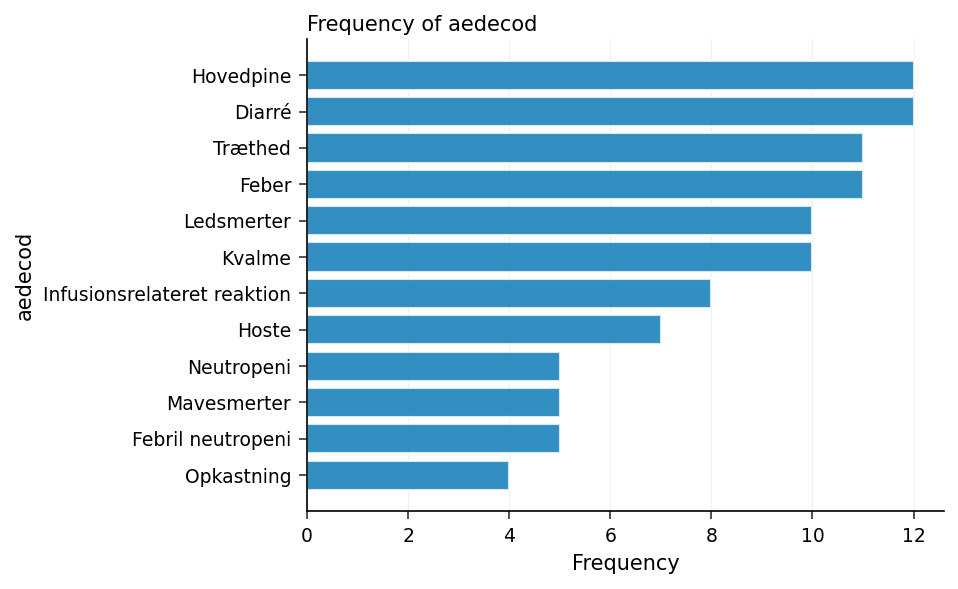

In [3]:
/* --------------------------------------------------------
   Rå frekvens af foretrukken term før SOC-kortlægning
   -------------------------------------------------------- */
PROCEDURE FREKVENSER data=work.ae_raw ORDER=FREKVENSER;
    TABLES aedecod / nocum;
    MÆRKAT aedecod = "Foretrukken term";
    TITEL 'Rå frekvens af foretrukken term (ikke-kodet)';
KØR;

---

                                      Rå frekvens af foretrukken term (ikke-kodet)                                      




NOTE: PROC SGPLOT data=work.ae_raw

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


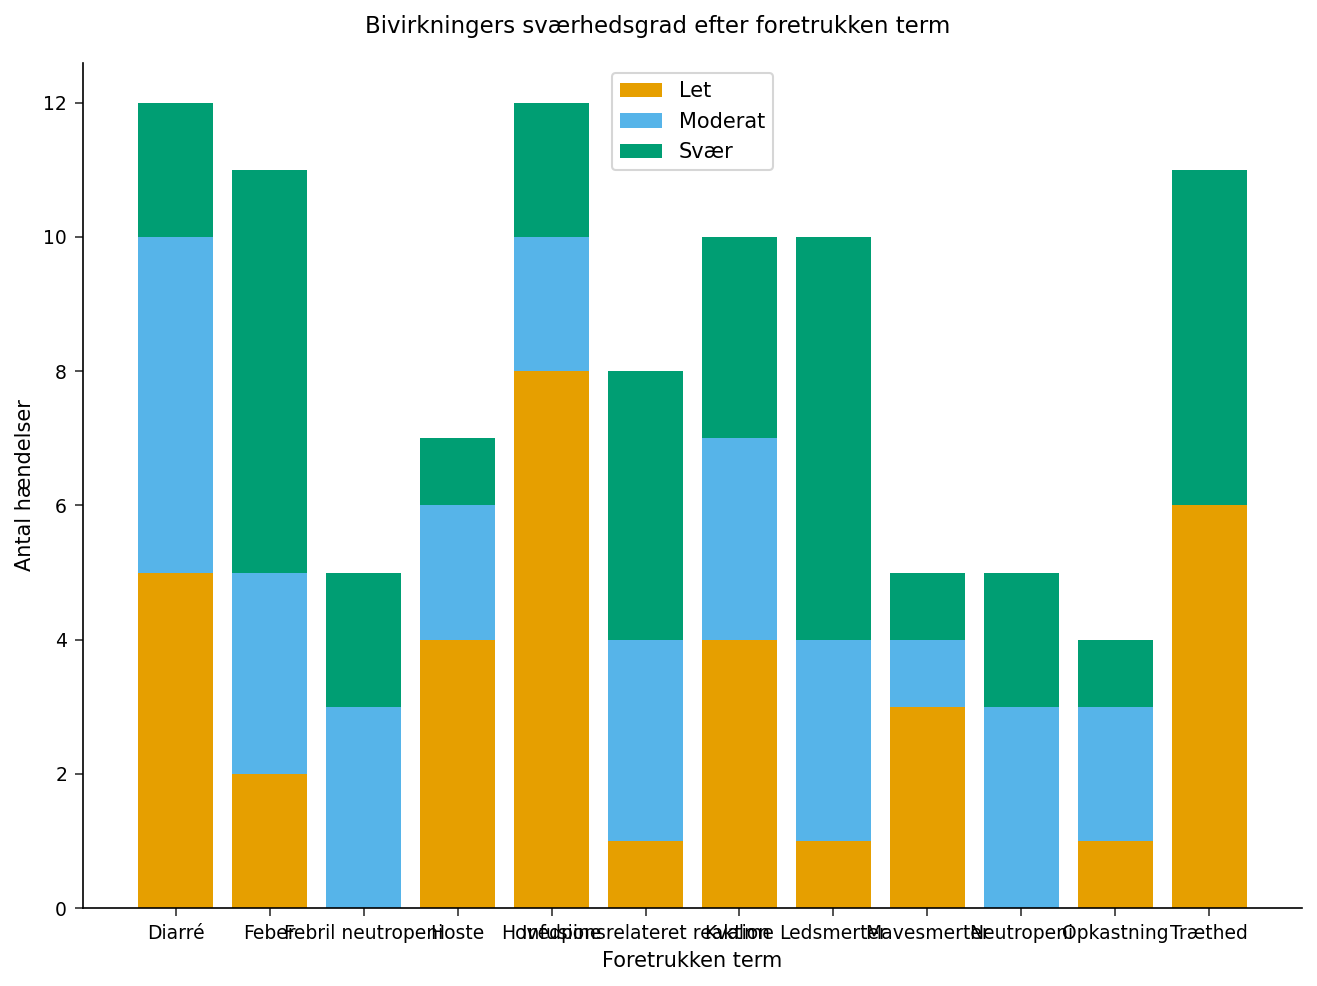

In [4]:
/* --------------------------------------------------------
   Bivirkningers sværhedsgrad efter foretrukken term
   -------------------------------------------------------- */
PROCEDURE SGPLOT data=work.ae_raw;
    VBAR aedecod / GROUP=aesev GROUPDISPLAY=stack;
    XAXIS MÆRKAT='Foretrukken term' fitpolicy=ROTATE;
    YAXIS MÆRKAT='Antal hændelser';
    TITEL 'Bivirkningers sværhedsgrad efter foretrukken term';
KØR;

---

In [5]:
/* --------------------------------------------------------
   Definér MedDRA foretrukken term -> organklasse (SOC)
   værdiformatet. Formatet er nøglet på den foretrukne terms
   tekst, så et enkelt PUT()-kald koder enhver bivirkning til
   dens SOC.
   -------------------------------------------------------- */
PROCEDURE format;
    VALUE $pt_to_soc
        'Kvalme'                      = 'Mave-tarm-sygdomme'
        'Opkastning'                  = 'Mave-tarm-sygdomme'
        'Diarré'                      = 'Mave-tarm-sygdomme'
        'Mavesmerter'                 = 'Mave-tarm-sygdomme'
        'Hovedpine'                   = 'Sygdomme i nervesystemet'
        'Træthed'                     = 'Almene lidelser'
        'Feber'                       = 'Almene lidelser'
        'Hoste'                       = 'Luftvejssygdomme'
        'Ledsmerter'                  = 'Muskel- og skeletsygdomme'
        'Neutropeni'                  = 'Blod- og lymfesystemsygdomme'
        'Febril neutropeni'           = 'Blod- og lymfesystemsygdomme'
        'Infusionsrelateret reaktion' = 'Immunsystemsygdomme'
        OTHER                         = 'Ikke-kodet'
    ;
    VALUE $sev_rank
        'Let'     = '1-Mild'
        'Moderat' = '2-Moderat'
        'Svær'    = '3-Svær'
        OTHER     = '9-Ukendt'
    ;
    VALUE $serious_fmt
        'Y' = 'Alvorlig'
        'N' = 'Ikke-alvorlig'
    ;
KØR;


NOTE: PROC FORMAT library=WORK

NOTE: FORMAT $pt_to_soc defined (13 ranges).
NOTE: FORMAT $sev_rank defined (4 ranges).
NOTE: FORMAT $serious_fmt defined (2 ranges).


In [6]:
/* --------------------------------------------------------
   Sammenflet bivirkningsrecords med behandlingsarm, anvend
   derefter SOC-formatet. SKRIV_V(aedecod, $pt_to_soc.) er det
   eneste kortlægningstrin, der er nødvendigt; sværhedsgrad og
   alvorlighed kodes på samme måde.
   -------------------------------------------------------- */
PROCEDURE SORTER data=work.ae_raw; EFTER usubjid; KØR;
PROCEDURE SORTER data=work.randomization; EFTER usubjid; KØR;

data work.ae_coded;
    LÆNGDE soc_class $32 severity_rank $12 serious_flag $16;
    SAMMENFLET work.ae_raw (IN=a)
          work.randomization (IN=b BEHOLD=usubjid treatment_arm);
    EFTER usubjid;
    HVIS a;
    soc_class     = SKRIV_V(aedecod, $pt_to_soc.);
    severity_rank = SKRIV_V(aesev,   $sev_rank.);
    serious_flag  = SKRIV_V(aeser,   $serious_fmt.);
KØR;


NOTE: PROC SORT data=work.ae_raw

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from work.ae_raw.
NOTE: Wrote work.ae_raw (100 rows, 10 columns).
NOTE: PROC SORT statement used.
NOTE: PROC SORT data=work.randomization

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from work.randomization.
NOTE: Wrote work.randomization (100 rows, 5 columns).
NOTE: PROC SORT statement used.
NOTE: DATA work.ae_coded

NOTE: Stream 1 processed 100 rows, max BY-group size: 3 (O(1) memory verified)
NOTE: Stream 2 processed 100 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote work.ae_coded (100 rows, 14 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds


                                Bivirkningsforekomst efter organklasse og behandlingsarm                                

                                                   The FREQ Procedure

Table of Organklasse (SOC) by Behandlingsarm

Organklasse (SOC)            |Aktiv komparator |      Forsøgsarm |         Placebo |            Total
-----------------------------+-----------------+-----------------+-----------------+-----------------
Almene lidelser              |               1 |               1 |               3 |                5
-----------------------------+-----------------+-----------------+-----------------+-----------------
Blod- og lymfesystemsygdomme |               0 |               1 |               1 |                2
-----------------------------+-----------------+-----------------+-----------------+-----------------
Immunsystemsygdomme          |               0 |               1 |               1 |                2
-----------------------------+-----------------


NOTE: ODS OUTPUT: ONEWAYFREQS -> soc_freq_table
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_soc_class_treatment_arm.spec.json
NOTE: ODS plot written: freq_mosaic_soc_class_severity_rank.spec.json
NOTE: PROC FREQ statement used.
NOTE: ODS OUTPUT: All output destinations closed.


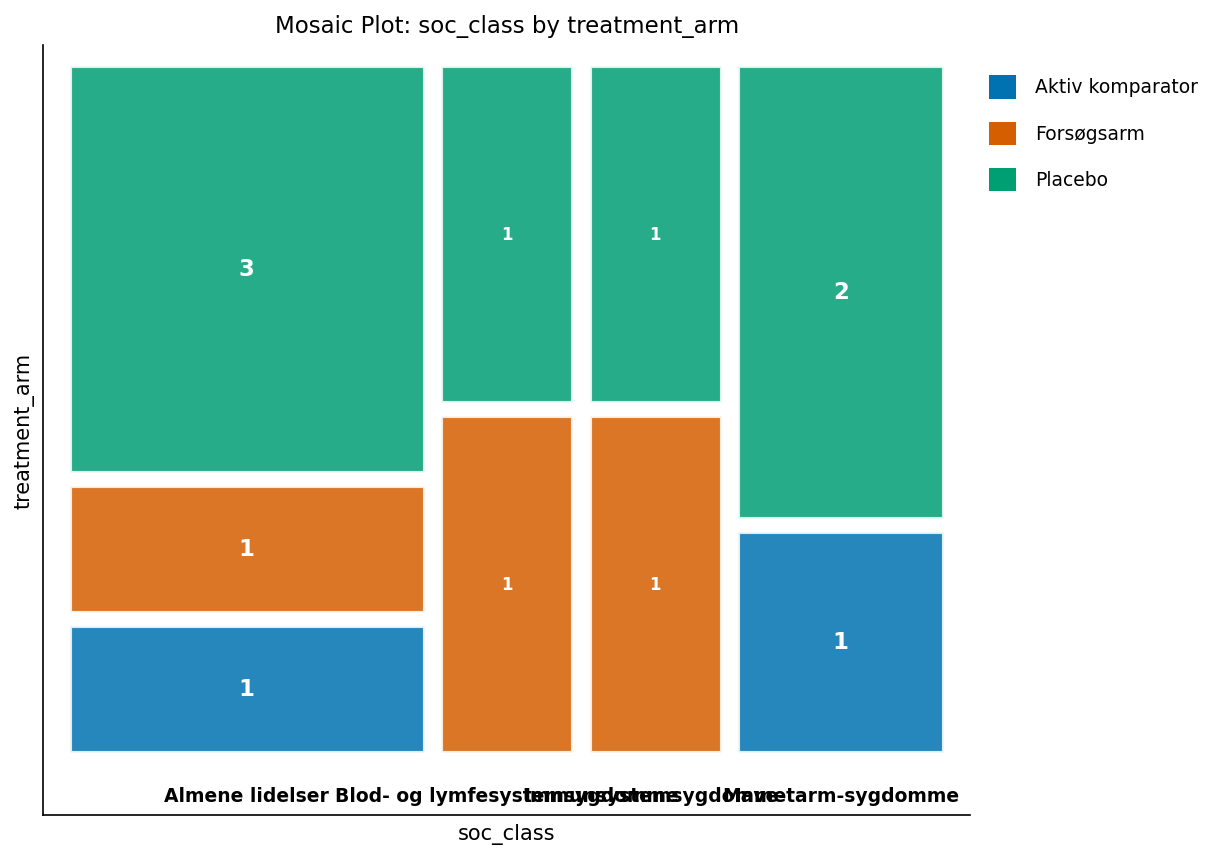

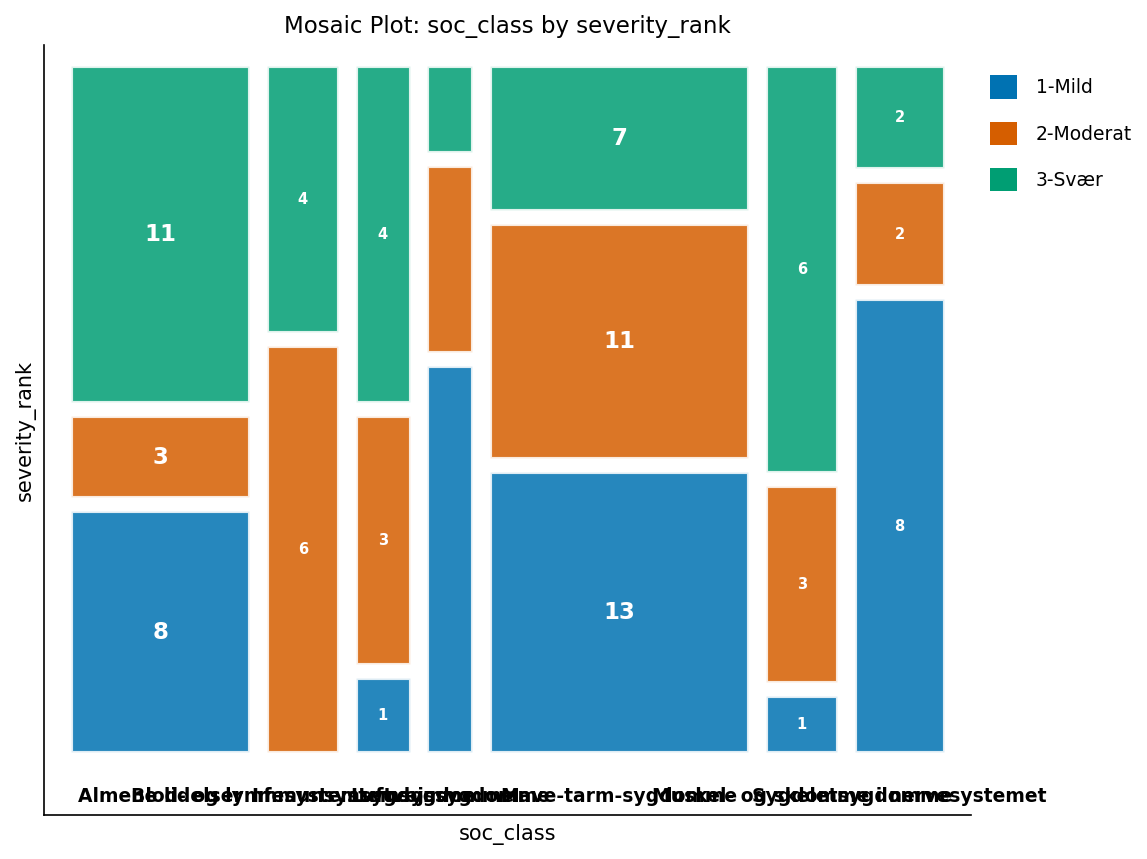

In [7]:
/* --------------------------------------------------------
   SOC-frekvens efter behandlingsarm
   ODS OUTPUT opfanger resultater til signaldetektion
   -------------------------------------------------------- */
ODS UDDATA onewayfreqs=work.soc_freq_table;

PROCEDURE FREKVENSER data=work.ae_coded ORDER=FREKVENSER;
    TABLES soc_class * treatment_arm / nocol nopercent;
    TABLES soc_class * severity_rank / nocol nopercent;
    MÆRKAT soc_class = "Organklasse (SOC)"
           treatment_arm = "Behandlingsarm"
           severity_rank = "Sværhedsgrad";
    TITEL 'Bivirkningsforekomst efter organklasse og behandlingsarm';
KØR;

ODS UDDATA CLOSE;

                               Alvorlige bivirkninger efter organklasse og behandlingsarm                               

                                                   The FREQ Procedure

Table of Organklasse (SOC) by Behandlingsarm

Organklasse (SOC)   |Aktiv komparator |      Forsøgsarm |         Placebo |            Total
--------------------+-----------------+-----------------+-----------------+-----------------
Almene lidelser     |               1 |               1 |               1 |                3
--------------------+-----------------+-----------------+-----------------+-----------------
Immunsystemsygdomme |               0 |               0 |               1 |                1
--------------------+-----------------+-----------------+-----------------+-----------------
Total               |               1 |               1 |               2 |                4




NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_soc_class_treatment_arm.spec.json
NOTE: PROC FREQ statement used.


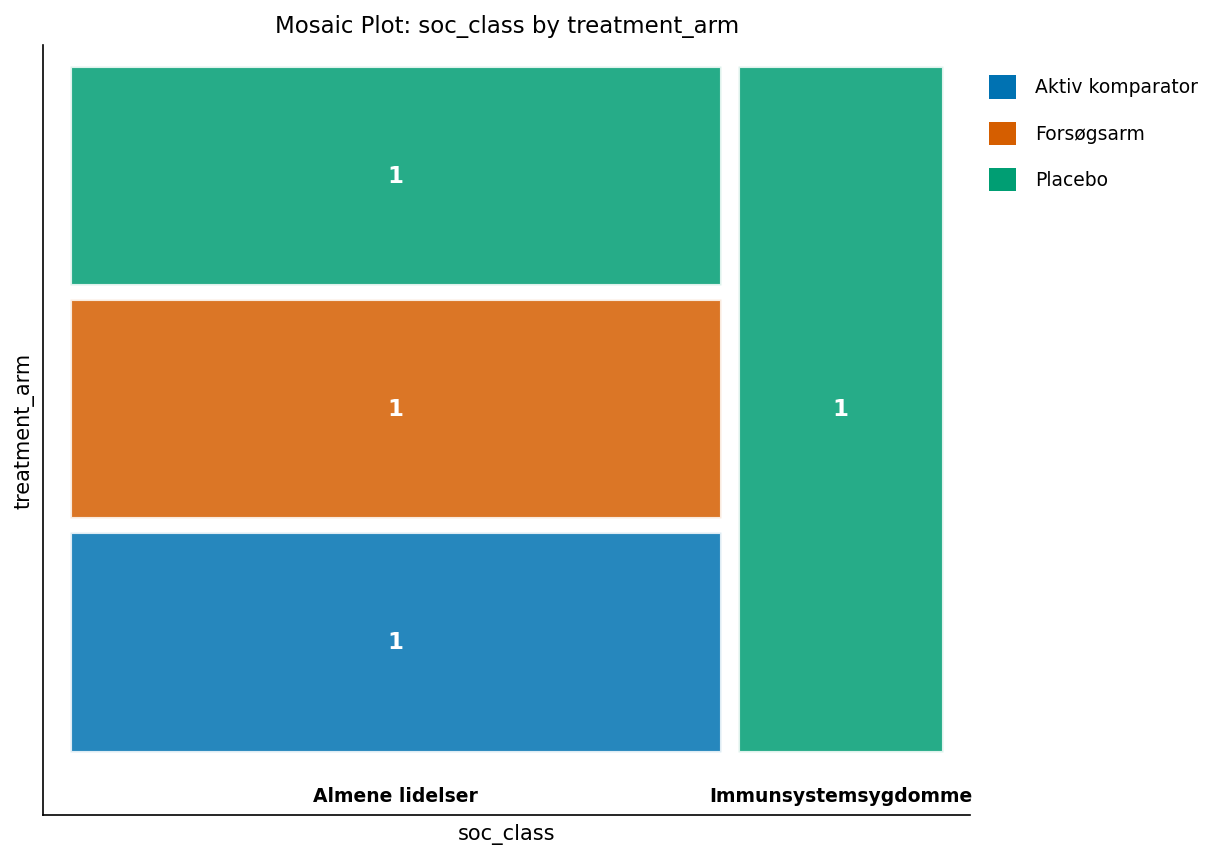

In [8]:
/* --------------------------------------------------------
   Oversigt over alvorlige bivirkninger efter SOC til
   sikkerhedsnarrativet
   -------------------------------------------------------- */
PROCEDURE FREKVENSER data=work.ae_coded;
    HVOR aeser = 'Y';
    TABLES soc_class * treatment_arm / nocol nopercent;
    MÆRKAT soc_class = "Organklasse (SOC)"
           treatment_arm = "Behandlingsarm";
    TITEL 'Alvorlige bivirkninger efter organklasse og behandlingsarm';
KØR;

---

### Fortolkning

Et enkelt `$pt_to_soc`-værdiformat kodede alle 100 bivirkninger fra 12
indrapporterede MedDRA foretrukne termer til 7 organklasser (SOC), og
dette ene format drev hver tabel nedenfor uden at omkode data.

Efter SOC og sværhedsgrad er **Mave-tarm-sygdomme** den hyppigste klasse
med 31 ud af 100 hændelser (13 lette, 11 moderate, 7 svære), efterfulgt
af **Almene lidelser** med 22 hændelser. De øvrige klasser er mindre:
Sygdomme i nervesystemet (12), Blod- og lymfesystemsygdomme (10),
Muskel- og skeletsygdomme (10), Immunsystemsygdomme (8) og
Luftvejssygdomme (7). På tværs af alle hændelser er sværhedsfordelingen
35 lette, 30 moderate og 35 svære.

Kun 4 hændelser blev markeret som alvorlige (`aeser='Y'`): 3 i Almene
lidelser (én pr. arm) og 1 i Immunsystemsygdomme (placebo).
Krydstabuleringen af SOC efter behandlingsarm er opbygget af de 12
hændelser, hvis forsøgsperson matchede en randomiseringsrecord, så
tallene på armniveau er illustrative snarere end powered til en
sammenligning mellem arme.

Den centrale pointe er FORMAT-mekanismen, ikke de syntetiske tal: fordi
kortlægningen fra foretrukken term til SOC udelukkende findes i PROC
FORMAT, omkoder det samme `SKRIV_V(aedecod, $pt_to_soc.)`-kald hele
datasættet, og en opdatering til en ny MedDRA-ordbogsversion betyder, at
man redigerer ét format frem for hver rapport. ODS OUTPUT opfangede
SOC-frekvenserne som `work.soc_freq_table` til efterfølgende
signalgennemgang.

---

In [9]:
/* --------------------------------------------------------
   Eksportér det SOC-kodede bivirkningsdatasæt til
   sikkerhedssignalgennemgang. Det ene $pt_to_soc-format har
   udfyldt soc_class, så den eksporterede fil er klar til
   efterfølgende SOC-niveau-analyse.
   -------------------------------------------------------- */
PROCEDURE EKSPORTERE data=work.ae_coded
    OUTFILE='ae_soc_coded.csv'
    DBMS=csv REPLACE;
KØR;


NOTE: PROC EXPORT data=work.ae_coded outfile=ae_soc_coded.csv

NOTE: Exported 100 rows to ae_soc_coded.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Fortroligt
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Drevet af <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>